In [70]:
dnd5rulebooklink = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"

import requests

# Link do PDF e caminho local para salvar
pdf_url = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"

# Baixar o PDF
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)


In [72]:
from PyPDF2 import PdfReader

# Caminhos
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"
output_json_path = "spells_dnd5e.json"

# Ler o PDF
reader = PdfReader(pdf_path)

# Extrair o texto cru
extracted_text = ""
spells_pages = []

start_page = 212
end_page = 288

# using this range
# notes para o markdown as paginas com magias estao no intervalo 213-288 de paginas por isso foi necessario usar esse range
for i in range(start_page, end_page):  # 213-288 inclusive
    page = reader.pages[i]
    text = page.extract_text()
    if text:
        text = text.strip()
        extracted_text += text + "\n\n"

with open(output_md_path, "w", encoding="utf-8") as f:
    f.write(extracted_text)

print("Arquivos salvos sem formatação extra.")


Arquivos salvos sem formatação extra.


In [28]:
import re

# Carrega o texto original
with open("spells_dnd5e.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Lista com blocos de magia
spells_array = []
current_spell = []
collecting = False

for i in range(1, len(lines)):
    if "nível de" in lines[i].lower():
        if collecting and current_spell:
            spells_array.append("".join(current_spell).strip())
            current_spell = []

        current_spell = [lines[i - 1], lines[i]]
        collecting = True
    elif collecting:
        current_spell.append(lines[i])

# Adiciona o último feitiço
if current_spell:
    spells_array.append("".join(current_spell).strip())

# Salva o novo .md com separadores
with open("spells_dnd5e_separado.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(spells_array))

print(f"{len(spells_array)} magias separadas com '---' e salvas em spells_dnd5e_separado.md")





364 magias separadas com '---' e salvas em spells_dnd5e_separado.md


In [33]:
# o texto de contagem de paginas eh bem inutil da silva, preciso remover as ocnecias dele a forca

# remove as recorencias das paginas entre esses valores
import re

start_page = 212
end_page = 288

# Carregar o texto
with open("spells_dnd5e_separado.md", "r", encoding="utf-8") as f:
    text = f.read()

# Lista para armazenar ocorrências encontradas
found_occurrences = []

# Regex que pega ocorrências de números de página em qualquer posição, mas isoladas por limites de palavra ou pontuação
for page_num in range(start_page, end_page + 1):
    # Procura o número entre espaços, pontuação ou quebras de linha
    matches = re.findall(rf"(?<!\d)\b{page_num}\b(?!\d)", text)
    if matches:
        found_occurrences.extend([str(page_num)] * len(matches))

# Exibir o que foi encontrado
print(f"{len(found_occurrences)} ocorrências de números de página entre {start_page} e {end_page} detectadas.")
print("Exemplos únicos encontrados:", sorted(set(found_occurrences)))

# Substituir essas ocorrências por string vazia
for page_num in range(start_page, end_page + 1):
    # Substitui com cuidado para não afetar números maiores que contenham os dígitos
    text = re.sub(rf"(?<!\d)\b{page_num}\b(?!\d)", "", text)

# Salvar o texto limpo
with open("spells_dnd5e_limpo.md", "w", encoding="utf-8") as f:
    f.write(text)

print("Texto limpo salvo em spells_dnd5e_limpo.md")


96 ocorrências de números de página entre 212 e 288 detectadas.
Exemplos únicos encontrados: ['216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '252', '253', '254', '255', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '267', '268', '269', '270', '271', '272', '273', '274', '275', '276', '277', '278', '279', '280', '281', '282', '283', '284', '285', '286', '287', '288']
Texto limpo salvo em spells_dnd5e_limpo.md


RAFAEL MAGNO FREITAS NUNES

In [12]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter



# generic multi class nlp
# TODO (s4hlo) collect portuguese data 
# mock data
# 0 - negative
# 1 - neutral
# 2 - positive
data = [
    {"selftext": "Adorei esse produto, me surpreendeu!", "target": 2},
    {"selftext": "Não odeio horrivel gostei da qualidade, deixou a desejar.", "target": 0},
    {"selftext": "É ok, nada demais também.", "target": 1},
    {"selftext": "O atendimento foi excelente, recomendo.", "target": 2},
    {"selftext": "Demorou pessimo muito pra chegar, fiquei frustrado.", "target": 0},
    {"selftext": "Cumpre o que promete, tudo certo.", "target": 2},
    {"selftext": "Mais ou menos, esperava mais.", "target": 1},
    {"selftext": "Veio  odio pessimo  quebrado, não funcionou.", "target": 0},
    {"selftext": "Maravilhoso! Com certeza compraria de novo.", "target": 2},
    {"selftext": "É aceitável pelo preço, mas não é top.", "target": 1},
]

df = pd.DataFrame(data)

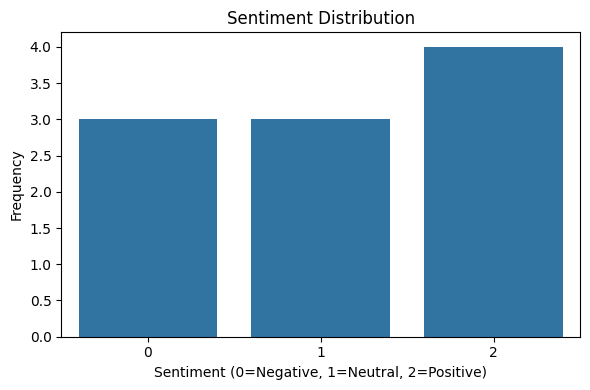

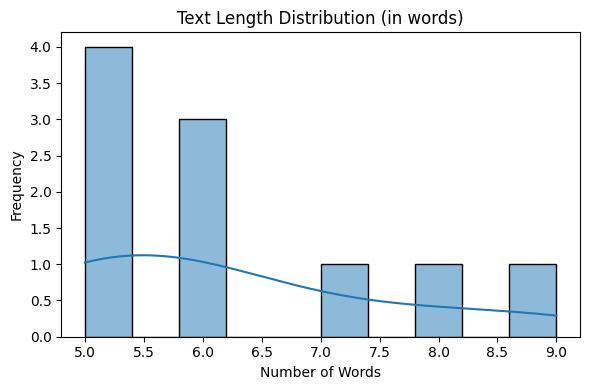

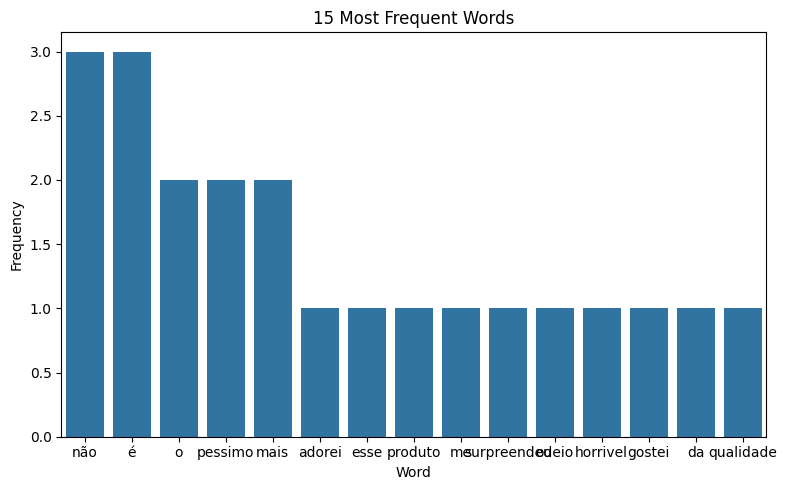

In [6]:


# TODO (s4hlo) check more relevant metrics

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Neutral, 2=Positive)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df["text_length"] = df["selftext"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=10, kde=True)
plt.title("Text Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

all_words = [word for text in df["selftext"] for word in tokenize(text)]
word_freq = Counter(all_words).most_common(15)
words, freqs = zip(*word_freq)

plt.figure(figsize=(8, 5))
sns.barplot(y=list(freqs), x=list(words),)
plt.title("15 Most Frequent Words")
plt.ylabel("Frequency")
plt.xlabel("Word")
plt.tight_layout()
plt.show()

/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sleight/.cache/pypoetry/virtualenvs/pln-qWjcxHse-py3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


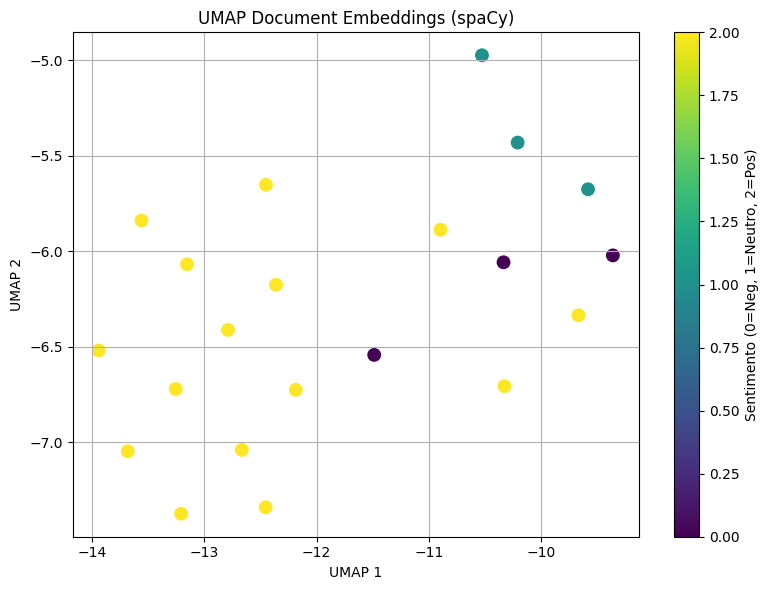

In [11]:
import spacy
import numpy as np
import umap

nlp = spacy.load("pt_core_news_md")

df["embedding"] = df["selftext"].apply(lambda x: nlp(x).vector)

X = np.vstack(df["embedding"].values)
y = df["target"].values

X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y,  s=80)
plt.title("UMAP Document Embeddings (spaCy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Sentimento (0=Neg, 1=Neutro, 2=Pos)")
plt.grid(True)
plt.tight_layout()
plt.show()

pos coleta de dados - tratamento

In [11]:
def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(lambda x: [make_lowercase(i) for i in x], validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(lambda x: [remove_excessive_whitespace(i) for i in x], validate=False)),
    ]
)

def safe_clean_text(x):
    try:
        return pipeline_clean_text.transform([str(x)])[0]
    except Exception:
        return x

df["selftext"] = df["selftext"].apply(safe_clean_text)

print("First 5 cleaned texts:")
for i in range(min(5, len(df))):
    print(f"\nText {i + 1}:")
    print(f"Content: {df['selftext'].iloc[i]}")



First 5 cleaned texts:

Text 1:
Content: adorei esse produto, me surpreendeu!

Text 2:
Content: não gostei da qualidade, deixou a desejar.

Text 3:
Content: é ok, nada demais também.

Text 4:
Content: o atendimento foi excelente, recomendo.

Text 5:
Content: demorou muito pra chegar, fiquei frustrado.


In [ ]:
# ------ split 1

# Display the first few rows of the DataFrame
# Drop the 'url' and 'id' columns from the DataFrame
df = df.drop(['url', 'id'], axis=1)

# Convert all text columns to lowercase
df['title'] = df['title'].str.lower()
df['selftext'] = df['selftext'].str.lower()

# Print the first 5 texts from the DataFrame
print("First 5 texts:")
for i in range(5):
    print(f"\nText {i+1}:")
    print(f"Title: {df['title'].iloc[i]}")
    print(f"Selftext: {df['selftext'].iloc[i]}")



# Get the most common words in selftext
from collections import Counter
import re

# Combine all selftext into one string and split into words
all_text = ' '.join(df['selftext'].dropna().astype(str))
words = re.findall(r'\w+', all_text.lower())

# Count word frequencies
word_counts = Counter(words)

# Get the 20 most common words
most_common = word_counts.most_common(20)

# Print the results
print("Most common words in selftext:")
for word, count in most_common:
    print(f"{word}: {count}")






df

First 5 texts:

Text 1:
Title: android app to strengthen attention/focus
Selftext: hey /r/adhd,

check out my simple android app: [attention exercise](https://market.android.com/details?id=com.racecarlabs.apps.android.attentionexercise)

it's just a series of simple touchscreen drawing exercises that, with practice, noticeably improve attention span and focus.  a session really shouldn't take more than a couple of minutes!

if you've heard of the book [delivered from distraction](http://www.amazon.com/delivered-distraction-getting-attention-disorder/dp/034544230x), the app is based on the exercises that dr. hallowell recommends in the book. 

writing code while managing my adhd symptoms hasn't been easy, but i hope this is an encouragement to you!  it felt really good to ship version 1.

if you have feature ideas or bug reports, i'd love to hear them!



on my roadmap:

* optional daily notifications (exercises work best with daily practice)
* tracking improvements
* making it prettier

,title,selftext,score,num_comments,created_utc,created_datetime
0,android app to strengthen attention/focus,"hey /r/adhd,\n\ncheck out my simple android ap...",6,7.0,1315014480.0,2011-09-03 01:48:00
1,does anyone here have experience with imipramine?,my doctor has suggested it for add with anxiet...,4,1.0,1315051084.0,2011-09-03 11:58:04
2,"new study shows that for people with adhd, \n""...",NaN,22,11.0,1315174374.0,2011-09-04 22:12:54
3,what does the adhd test look like?,i'm 21 and didn't know about adhd until recent...,6,10.0,1315239683.0,2011-09-05 16:21:23
4,are you guys good with maps and directions?,it seems like one thing i've always been reall...,0,0.0,1315317191.0,2011-09-06 13:53:11
...,...,...,...,...,...,...
336061,meds not working / lack of sleep to blame?,hi everyone\n\ni started taking mph 2 weeks ag...,1,2.0,1613046880.0,2021-02-11 12:34:40
336062,how to deal with friends who tell you to be ca...,[deleted],2,7.0,1613047275.0,2021-02-11 12:41:15
336063,"atomoxetine side effects were too harsh, appre...",hello everyone!\n\ni’ve been a part of this su...,1,2.0,1613047850.0,2021-02-11 12:50:50
336064,lto3 experiences,[removed],2,0.0,1613047852.0,2021-02-11 12:50:52
